In [1]:
# ── Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib

print(' All libraries imported successfully!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   sklearn imported')

 All libraries imported successfully!
   pandas  2.3.3
   numpy   2.3.5
   sklearn imported


In [2]:
# ── Load Dataset ─────────────────────────────────────
df = pd.read_csv('smart_university_guidance_dataset.csv')

print(' Dataset Shape:', df.shape)
print('\n Columns:')
for col in df.columns:
    print(f'   {col}: {df[col].dtype}')
print('\n First 5 rows:')
df.head()

 Dataset Shape: (1000, 11)

 Columns:
   Math_Skill: object
   Coding_Interest: object
   Creativity: object
   Communication: object
   Logical_Thinking: object
   Tech_Interest: object
   GPA: float64
   Study_Hours_Per_Day: float64
   Teamwork: object
   Problem_Solving: object
   Recommended_Field: object

 First 5 rows:


,Math_Skill,Coding_Interest,Creativity,Communication,Logical_Thinking,Tech_Interest,GPA,Study_Hours_Per_Day,Teamwork,Problem_Solving,Recommended_Field
0,Medium,Medium,Medium,Medium,High,High,3.678357,10.798711,Medium,High,Cyber Security
1,Medium,High,Low,Low,Low,High,3.770868,6.849267,Low,Medium,Cyber Security
2,Low,Medium,Low,Low,Medium,Low,4.000000,6.119261,High,Medium,Data Science
3,Low,Medium,High,Low,Medium,Medium,3.291515,2.000000,Medium,Low,Web Development
4,Medium,Medium,High,Low,High,Medium,3.822923,4.396447,High,Medium,Web Development


In [3]:
# ── Exploratory Data Analysis ────────────────────────
print('  Basic Statistics:')
print(df.describe())

print('\n Career Distribution:')
career_counts = df['Recommended_Field'].value_counts()
print(career_counts)

print('\n Missing Values:')
print(df.isnull().sum())

  Basic Statistics:
               GPA  Study_Hours_Per_Day
count  1000.000000          1000.000000
mean      2.996181             7.034455
std       0.636422             3.233935
min       2.000000             2.000000
25%       2.459557             4.383390
50%       2.988292             7.018363
75%       3.528548             9.706951
max       4.000000            12.000000

 Career Distribution:
Recommended_Field
Data Science               556
Web Development            204
App Development            109
Cyber Security              83
Artificial Intelligence     48
Name: count, dtype: int64

 Missing Values:
Math_Skill             0
Coding_Interest        0
Creativity             0
Communication          0
Logical_Thinking       0
Tech_Interest          0
GPA                    0
Study_Hours_Per_Day    0
Teamwork               0
Problem_Solving        0
Recommended_Field      0
dtype: int64


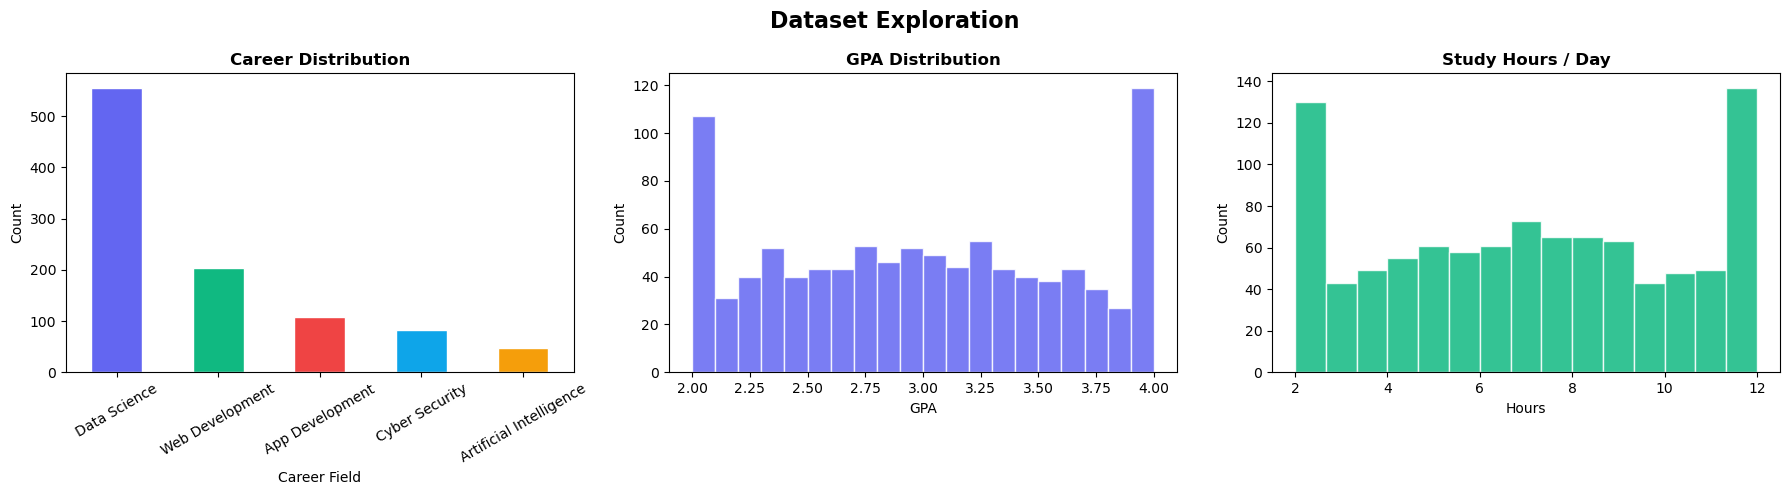

 EDA charts saved!


In [4]:
# ── EDA Charts ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Exploration', fontsize=16, fontweight='bold')

# 1. Career distribution
colors = ['#6366f1','#10b981','#ef4444','#0ea5e9','#f59e0b']
career_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Career Distribution', fontweight='bold')
axes[0].set_xlabel('Career Field')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# 2. GPA distribution
axes[1].hist(df['GPA'], bins=20, color='#6366f1', edgecolor='white', alpha=0.85)
axes[1].set_title('GPA Distribution', fontweight='bold')
axes[1].set_xlabel('GPA')
axes[1].set_ylabel('Count')

# 3. Study hours distribution
axes[2].hist(df['Study_Hours_Per_Day'], bins=15, color='#10b981', edgecolor='white', alpha=0.85)
axes[2].set_title('Study Hours / Day', fontweight='bold')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print(' EDA charts saved!')

In [5]:
# ── Preprocessing ────────────────────────────────────
df_enc = df.copy()

# Encode categorical skill columns
skill_map = {'Low': 0, 'Medium': 1, 'High': 2}
cat_cols = [
    'Math_Skill', 'Coding_Interest', 'Creativity', 'Communication',
    'Logical_Thinking', 'Tech_Interest', 'Teamwork', 'Problem_Solving'
]
for col in cat_cols:
    df_enc[col] = df_enc[col].map(skill_map)

# Encode target
le = LabelEncoder()
df_enc['Recommended_Field'] = le.fit_transform(df_enc['Recommended_Field'])

print(' Encoding done!')
print(f'   Career classes: {list(le.classes_)}')
print('\n📋 Encoded Sample:')
df_enc.head(3)

 Encoding done!
   Career classes: ['App Development', 'Artificial Intelligence', 'Cyber Security', 'Data Science', 'Web Development']

📋 Encoded Sample:


,Math_Skill,Coding_Interest,Creativity,Communication,Logical_Thinking,Tech_Interest,GPA,Study_Hours_Per_Day,Teamwork,Problem_Solving,Recommended_Field
0,1,1,1,1,2,2,3.678357,10.798711,1,2,2
1,1,2,0,0,0,2,3.770868,6.849267,0,1,2
2,0,1,0,0,1,0,4.000000,6.119261,2,1,3


## NLP Module — Free-Text Skill Extraction

The web app supports an alternative input mode where a student writes a free-text paragraph about themselves instead of filling the dropdown form above. Since this produces the **same kind of numeric skill features** as the dropdown encoding (Section: Preprocessing), it is placed here, right after preprocessing and before the train/test split.

The pipeline (implemented in `nlp_module.py`, shared with the Flask app `app.py`) follows standard NLP preprocessing steps:

1. **Tokenization** — splitting the paragraph into individual words (`nltk.word_tokenize`)
2. **Lowercasing & Punctuation Removal** — cleaning the tokens
3. **Stopword Removal** — removing common words ("the", "is", "a"...) that carry no skill information (`nltk.corpus.stopwords`)
4. **Stemming** — reducing words to their root form, e.g. "coding"/"coded"/"codes" → "code" (`nltk.stem.PorterStemmer`)
5. **Keyword Matching & Scoring** — counting stemmed keyword matches per skill category to assign a Low(0) / Medium(1) / High(2) score

Because both this notebook and `app.py` import the exact same `parse_nlp_text()` function from `nlp_module.py`, the NLP logic used for live predictions on the website is identical to what is demonstrated and tested here.

In [ ]:
# Import the SAME nlp_module.py used by app.py (Flask backend)
from nlp_module import preprocess_text, parse_nlp_text, NLP_KEYWORDS_STEMMED

# Demonstrate each preprocessing stage on a sample sentence
demo_text = "I love solving math problems and analyzing data. I enjoy coding in Python!"

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re

stop_words = set(stopwords.words('english'))

print("Original text   :", demo_text)
print("Tokenized        :", word_tokenize(demo_text.lower()))
cleaned = re.sub(r'[^a-z\s]', ' ', demo_text.lower())
no_stopwords = [t for t in word_tokenize(cleaned) if t not in stop_words and len(t) > 1]
print("After stopwords  :", no_stopwords)
print("After stemming   :", preprocess_text(demo_text))

In [ ]:
# Test the full NLP pipeline on a sample free-text student description
sample_text = ("I love solving math problems and analyzing data. I enjoy coding in Python "
               "and building logical systems. I am interested in technology and often spend "
               "time on GitHub. I work well in teams and enjoy explaining complex ideas to "
               "others. I am good at problem solving and finding creative solutions")

print("Preprocessed tokens:", preprocess_text(sample_text))
print()
extracted_scores = parse_nlp_text(sample_text)
print("Extracted skill scores from free text:")
for skill, score in extracted_scores.items():
    label = {0: "Low", 1: "Medium", 2: "High"}[score]
    print(f"  {skill:10s} -> {score} ({label})")

In [7]:
# ── Feature Selection & Train/Test Split ─────────────
FEATURES = [
    'Math_Skill', 'Coding_Interest', 'Creativity', 'Communication',
    'Logical_Thinking', 'Tech_Interest', 'Teamwork', 'Problem_Solving',
    'GPA', 'Study_Hours_Per_Day'
]

X = df_enc[FEATURES].values
y = df_enc['Recommended_Field'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f' Dataset Split:')
print(f'   Total samples : {len(X)}')
print(f'   Training set  : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Test set      : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')
print(f'   Features used : {len(FEATURES)}')

 Dataset Split:
   Total samples : 1000
   Training set  : 750 (75%)
   Test set      : 250 (25%)
   Features used : 10


In [8]:
# ── Train All 4 Models ───────────────────────────────

# 1. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test_s))
print(f' KNN                 : {knn_acc*100:.2f}%')

# 2. SVM
svm = SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=42)
svm.fit(X_train_s, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test_s))
print(f' SVM                 : {svm_acc*100:.2f}%')

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_s, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test_s))
print(f' Random Forest       : {rf_acc*100:.2f}%  ← BEST')

# 4. Logistic Regression
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_s, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_s))
print(f' Logistic Regression : {lr_acc*100:.2f}%')

results = {
    'KNN':                knn_acc,
    'SVM':                svm_acc,
    'Random Forest':      rf_acc,
    'Logistic Regression':lr_acc
}
best_name  = max(results, key=results.get)
best_model = {'KNN':knn,'SVM':svm,'Random Forest':rf,'Logistic Regression':lr}[best_name]
print(f'\n Best Model: {best_name} ({results[best_name]*100:.2f}%)')

 KNN                 : 82.00%
 SVM                 : 93.60%
 Random Forest       : 96.00%  ← BEST
 Logistic Regression : 92.80%

 Best Model: Random Forest (96.00%)


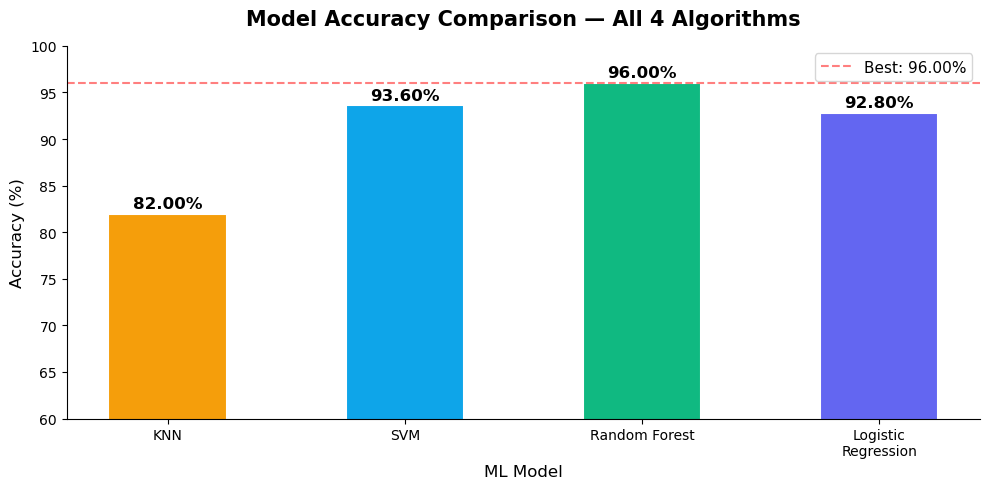

 Model comparison chart saved!


In [9]:
# ── Model Comparison Chart ───────────────────────────
model_names = ['KNN', 'SVM', 'Random Forest', 'Logistic\nRegression']
accuracies  = [knn_acc*100, svm_acc*100, rf_acc*100, lr_acc*100]
bar_colors  = ['#f59e0b', '#0ea5e9', '#10b981', '#6366f1']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names, accuracies, color=bar_colors,
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=12)

ax.set_ylim(60, 100)
ax.set_title('Model Accuracy Comparison — All 4 Algorithms', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('ML Model', fontsize=12)
ax.axhline(y=max(accuracies), color='red', linestyle='--', alpha=0.5, label=f'Best: {max(accuracies):.2f}%')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Model comparison chart saved!')

In [10]:
# ── Classification Report (Best Model) ───────────────
print(f' Classification Report — {best_name}\n')
print(classification_report(
    y_test,
    best_model.predict(X_test_s),
    target_names=le.classes_,
    zero_division=0
))

 Classification Report — Random Forest

                         precision    recall  f1-score   support

        App Development       0.95      0.84      0.89        25
Artificial Intelligence       1.00      0.91      0.95        11
         Cyber Security       0.94      0.84      0.89        19
           Data Science       0.96      0.99      0.97       151
        Web Development       0.98      0.98      0.98        44

               accuracy                           0.96       250
              macro avg       0.97      0.91      0.94       250
           weighted avg       0.96      0.96      0.96       250



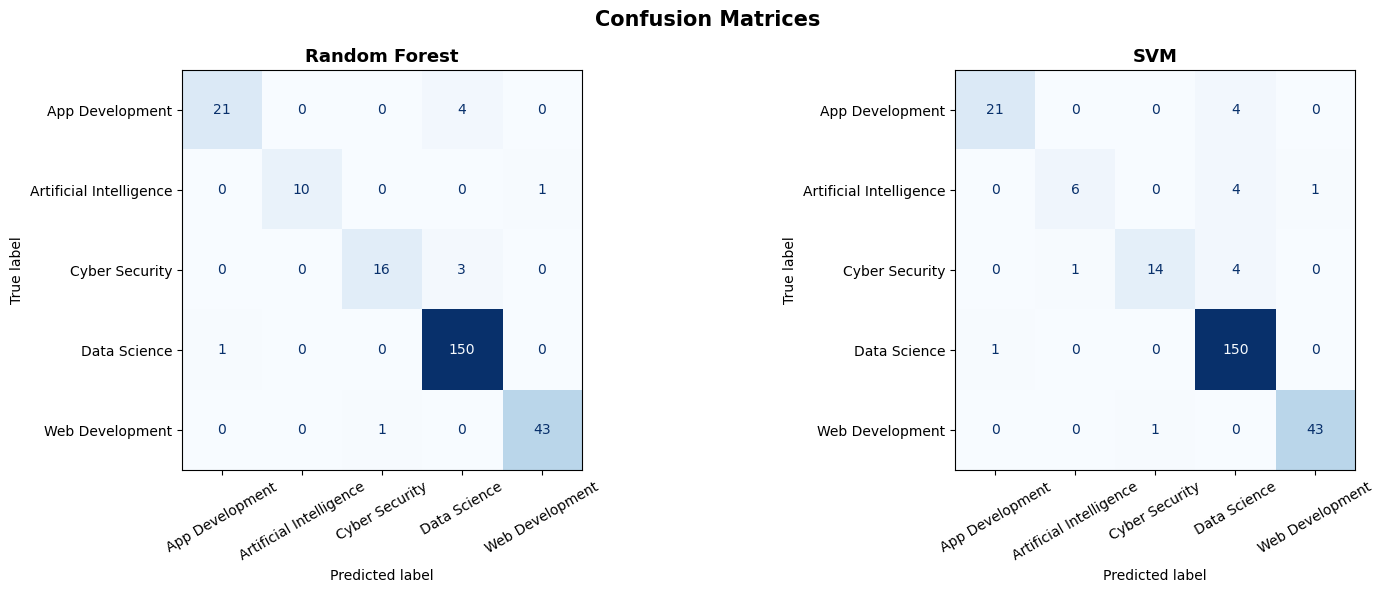

 Confusion matrices saved!


In [11]:
# ── Confusion Matrix ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')

for ax, (name, model) in zip(axes, [('Random Forest', rf), ('SVM', svm)]):
    cm = confusion_matrix(y_test, model.predict(X_test_s))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold', fontsize=13)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Confusion matrices saved!')

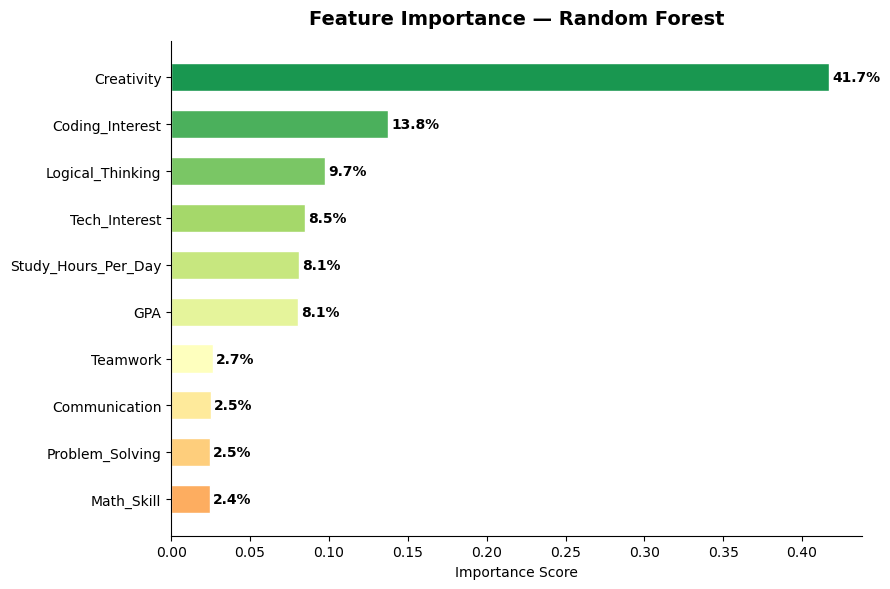

 Feature importance chart saved!


In [13]:
# ── Feature Importance (Random Forest) ───────────────
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(FEATURES)))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=colors_fi, edgecolor='white', height=0.6)

for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Feature importance chart saved!')

In [14]:
# ── Save All Models & Artifacts ──────────────────────
joblib.dump(best_model, 'career_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(le,         'label_encoder.pkl')
joblib.dump({
    'knn':      round(knn_acc*100, 2),
    'svm':      round(svm_acc*100, 2),
    'rf':       round(rf_acc*100, 2),
    'lr':       round(lr_acc*100, 2),
    'best':     best_name,
    'best_acc': round(results[best_name]*100, 2),
    'features': FEATURES
}, 'model_stats.pkl')

print(' All files saved:')
print('   career_model.pkl    ← Best model (Random Forest)')
print('   scaler.pkl          ← StandardScaler')
print('   label_encoder.pkl   ← Career label encoder')
print('   model_stats.pkl     ← All 4 model accuracies')
print(f'\n Best: {best_name} — {results[best_name]*100:.2f}%')

 All files saved:
   career_model.pkl    ← Best model (Random Forest)
   scaler.pkl          ← StandardScaler
   label_encoder.pkl   ← Career label encoder
   model_stats.pkl     ← All 4 model accuracies

 Best: Random Forest — 96.00%


In [15]:
# ── Test Prediction ───────────────────────────────────
# Feature order: Math, Coding, Creativity, Communication,
#                Logic, Tech, Teamwork, Problem, GPA, StudyHours
# Low=0, Medium=1, High=2

test_student = np.array([[2, 2, 1, 1, 2, 2, 1, 2, 3.7, 5.0]])  # Strong AI/DS profile
test_scaled  = scaler.transform(test_student)
probas       = best_model.predict_proba(test_scaled)[0]

top3_idx = np.argsort(probas)[::-1][:3]
print('  Test Prediction (High Math, High Coding, High Logic):\n')
for i, idx in enumerate(top3_idx):
    print(f'   #{i+1} {le.classes_[idx]:25s} → {probas[idx]*100:.1f}%')

  Test Prediction (High Math, High Coding, High Logic):

   #1 Artificial Intelligence   → 65.0%
   #2 Cyber Security            → 17.5%
   #3 Data Science              → 10.0%


## NLP Input → Trained Model Prediction

Now that the Random Forest model is trained and saved above, we confirm that skills extracted from free text (via the NLP module defined earlier) feed into the **same trained model** and produce a valid top-3 career prediction — proving both input modes (dropdown and NLP) are connected to one shared model.

In [ ]:
# Feature order: Math, Coding, Creativity, Communication,
#                Logic, Tech, Teamwork, Problem, GPA, StudyHours
nlp_gpa = 3.0
nlp_study_hours = 7.0

nlp_feature_vector = np.array([[
    extracted_scores["math"],
    extracted_scores["coding"],
    extracted_scores["creative"],
    extracted_scores["comm"],
    extracted_scores["logic"],
    extracted_scores["tech"],
    extracted_scores["team"],
    extracted_scores["problem"],
    nlp_gpa,
    nlp_study_hours
]])

nlp_scaled = scaler.transform(nlp_feature_vector)
nlp_probas = best_model.predict_proba(nlp_scaled)[0]

top3_idx = np.argsort(nlp_probas)[::-1][:3]
print('  Top 3 Career Predictions from NLP free-text input:\n')
for i, idx in enumerate(top3_idx):
    print(f'   #{i+1} {le.classes_[idx]:25s} → {nlp_probas[idx]*100:.1f}%')